# Week 4 Day 3 — EDA at Scale

## What I built:
- ydata-profiling report on House Prices dataset
- Distribution analysis — skewness and kurtosis before/after log
- Q-Q plot — checked normality of log-transformed SalePrice
- Missing value bar chart + heatmap pattern
- Pairplot — top 6 features vs SalePrice
- reusable eda_summary() function saved to src/utils.py

## Key findings:

**Profile report:**
- 0 rejected variables
- OverallQual highest correlation with SalePrice
- 7829 missing cells (6.62%)
- Neighborhood has highest cardinality (25 unique values)
- Id flagged as uniform + unique → drop it

**Distribution:**
- SalePrice skewness: 1.88 → 0.12 after log transform
- SalePrice kurtosis: 6.54 → 0.81 after log transform
- Q-Q plot confirms log transform fixes normality

**Missing data strategy:**
- Drop >40% missing: PoolQC, MiscFeature, Alley, 
  Fence, MasVnrType, FireplaceQu (6 columns)
- Impute <40% missing: LotFrontage, Garage cols,
  Basement cols, Electrical (13 columns)

**Correlations with SalePrice:**
OverallQual : 0.791 ← strongest
GrLivArea   : 0.709
GarageCars  : 0.640
TotalBsmtSF : 0.614
YearBuilt   : 0.523 ← weakest of top 6

**Non-linear relationships:**
YearBuilt, TotalBsmtSF — tree models handle better than linear

# Install and run ydata-profiling:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# install ydata-profiling
import subprocess
subprocess.run(['pip', 'install', 'ydata-profiling', '--quiet'])

from ydata_profiling import ProfileReport

# load House Prices dataset
df = pd.read_csv('house_prices_train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# generate full profile report
profile = ProfileReport(df, title="House Prices EDA Report", 
                        explorative=True)
profile.to_file("house_prices_profile.html")
print("Profile report saved to house_prices_profile.html")

Dataset shape: (1460, 81)
Memory usage: 3516.45 KB


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 81/81 [00:03<00:00, 21.61it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report saved to house_prices_profile.html


# Distribution analysis on SalePrice:

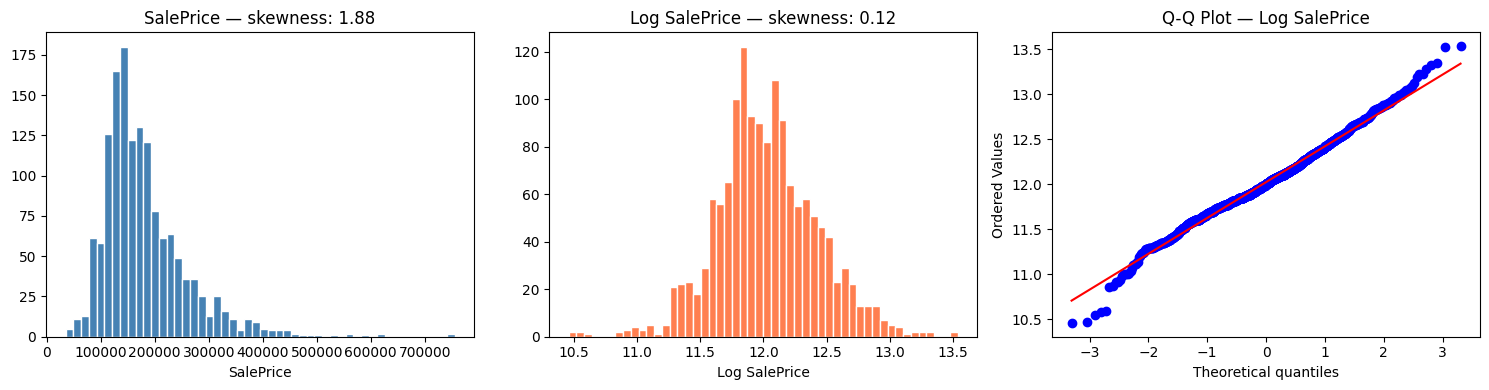

Original skewness : 1.8829
Log skewness      : 0.1213
Original kurtosis : 6.5363
Log kurtosis      : 0.8095


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# original distribution
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'SalePrice — skewness: {df["SalePrice"].skew():.2f}')
axes[0].set_xlabel('SalePrice')

# log transformed
log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'Log SalePrice — skewness: {log_price.skew():.2f}')
axes[1].set_xlabel('Log SalePrice')

# Q-Q plot
from scipy import stats
stats.probplot(log_price, plot=axes[2])
axes[2].set_title('Q-Q Plot — Log SalePrice')

plt.tight_layout()
plt.savefig('saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Original skewness : {df['SalePrice'].skew():.4f}")
print(f"Log skewness      : {log_price.skew():.4f}")
print(f"Original kurtosis : {df['SalePrice'].kurtosis():.4f}")
print(f"Log kurtosis      : {log_price.kurtosis():.4f}")

# Missing data map:

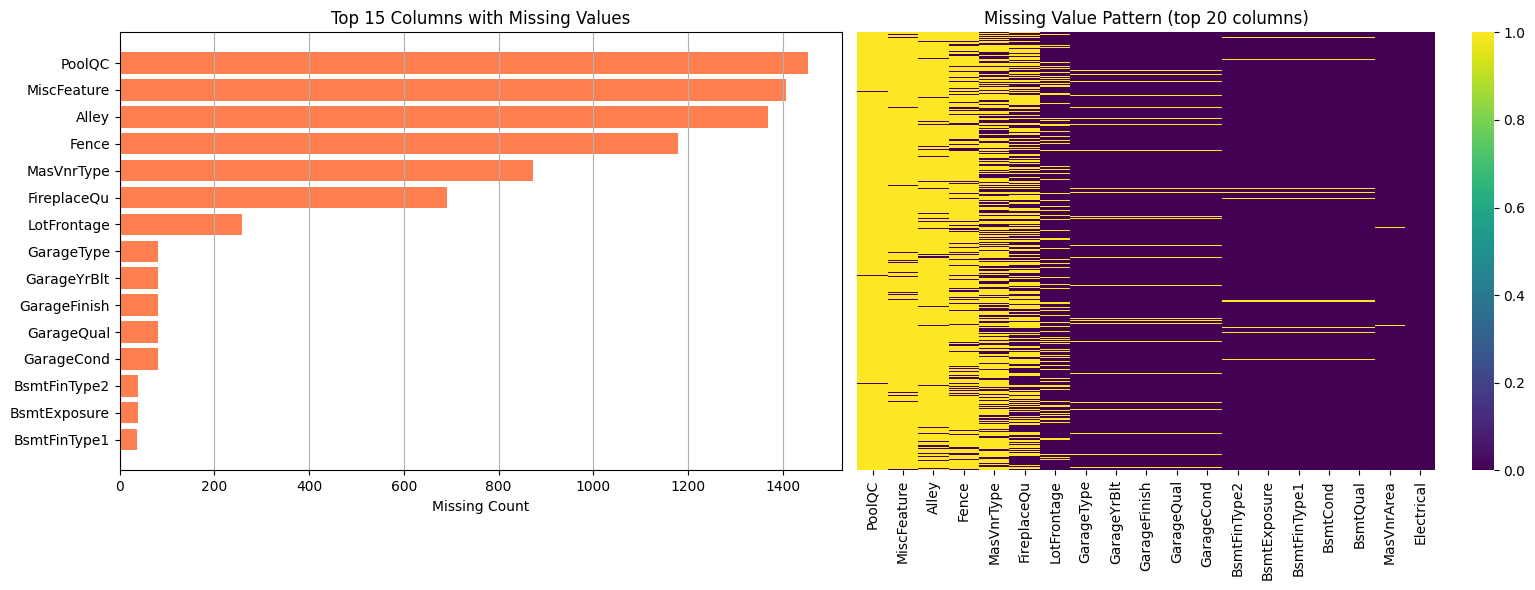

   MISSING DATA STRATEGY
  Total columns with missing : 19
  Drop (>40% missing)        : 6
  Impute (<40% missing)      : 13

  Columns to drop:
    PoolQC               : 99.5% missing
    MiscFeature          : 96.3% missing
    Alley                : 93.8% missing
    Fence                : 80.8% missing
    MasVnrType           : 59.7% missing
    FireplaceQu          : 47.3% missing

  Columns to impute:
    LotFrontage          : 17.7% missing
    GarageType           : 5.5% missing
    GarageYrBlt          : 5.5% missing
    GarageFinish         : 5.5% missing
    GarageQual           : 5.5% missing
    GarageCond           : 5.5% missing
    BsmtFinType2         : 2.6% missing
    BsmtExposure         : 2.6% missing
    BsmtFinType1         : 2.5% missing
    BsmtCond             : 2.5% missing
    BsmtQual             : 2.5% missing
    MasVnrArea           : 0.5% missing
    Electrical           : 0.1% missing


In [9]:
# missing value analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# bar chart — missing count
axes[0].barh(missing.index[:15], missing.values[:15], color='coral')
axes[0].set_title('Top 15 Columns with Missing Values')
axes[0].set_xlabel('Missing Count')
axes[0].invert_yaxis()
axes[0].grid(True, axis='x')

# heatmap — missing pattern
sns.heatmap(df[missing.index[:20]].isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Missing Value Pattern (top 20 columns)')

plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# categorize columns
drop_cols   = missing[missing > 0.4 * len(df)].index.tolist()
impute_cols = missing[missing <= 0.4 * len(df)].index.tolist()

print("=" * 50)
print("   MISSING DATA STRATEGY")
print("=" * 50)
print(f"  Total columns with missing : {len(missing)}")
print(f"  Drop (>40% missing)        : {len(drop_cols)}")
print(f"  Impute (<40% missing)      : {len(impute_cols)}")
print(f"\n  Columns to drop:")
for col in drop_cols:
    pct = missing[col] / len(df) * 100
    print(f"    {col:20} : {pct:.1f}% missing")
print(f"\n  Columns to impute:")
for col in impute_cols:
    pct = missing[col] / len(df) * 100
    print(f"    {col:20} : {pct:.1f}% missing")
print("=" * 50)

# Pairplot on top features:

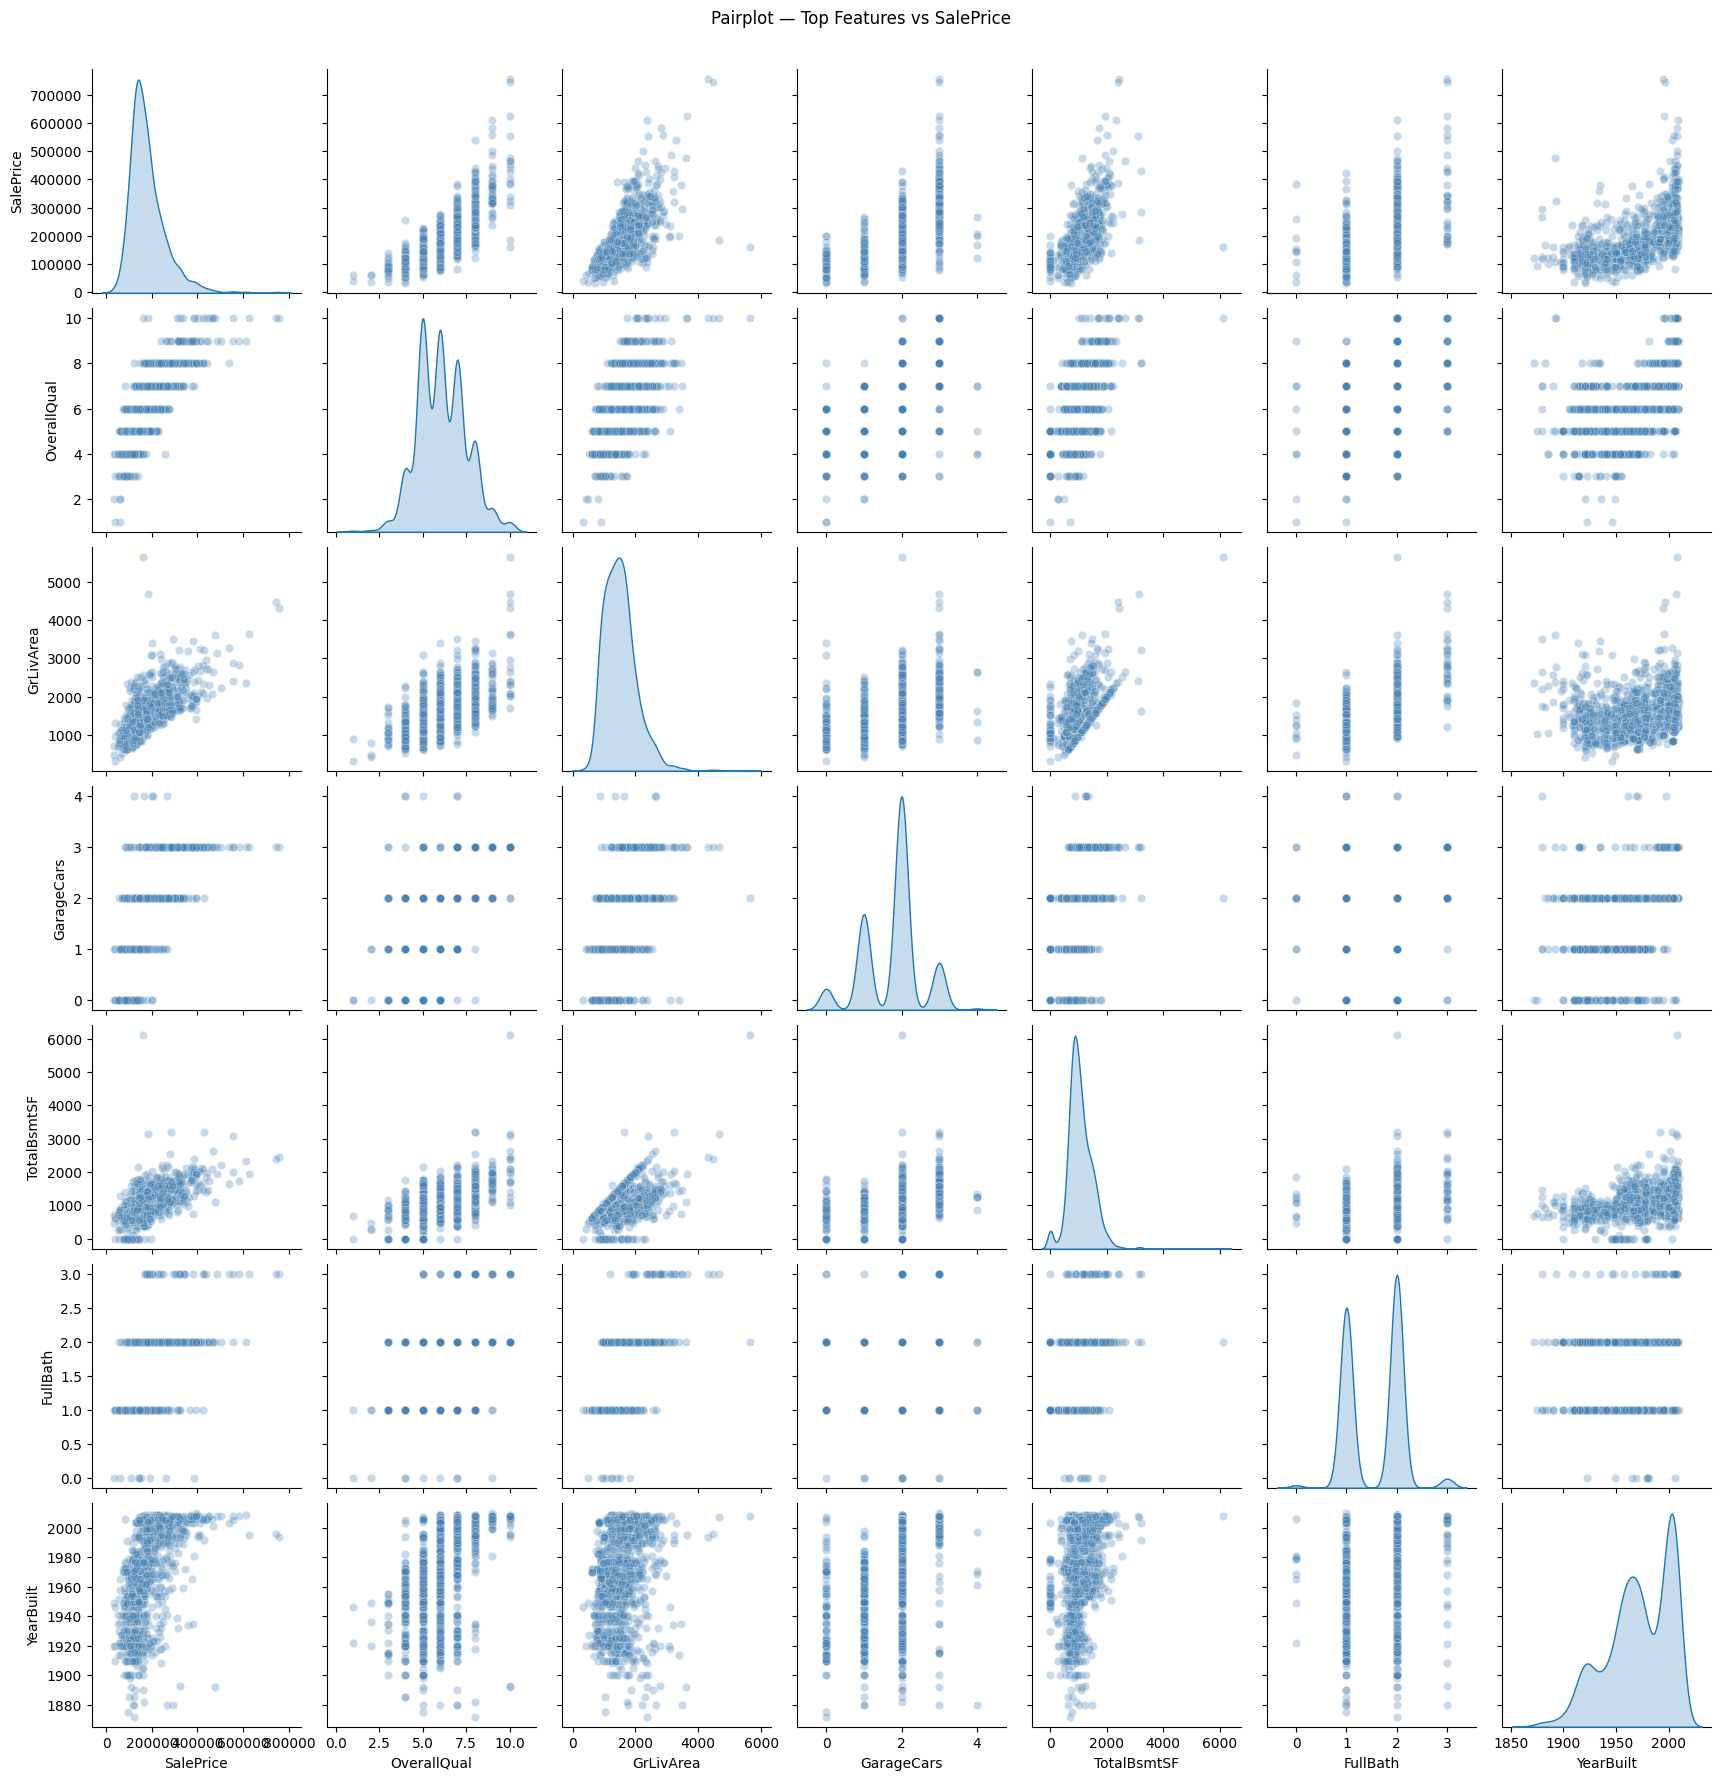

Correlation with SalePrice:
SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
TotalBsmtSF    0.613581
FullBath       0.560664
YearBuilt      0.522897
Name: SalePrice, dtype: float64


In [10]:
# select top 6 correlated features + target
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 
                'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

# pairplot
sns.pairplot(df[top_features], 
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 'color': 'steelblue'})
plt.suptitle('Pairplot — Top Features vs SalePrice', y=1.02)
plt.savefig('pairplot_top_features.png', dpi=100, bbox_inches='tight')
plt.show()

# correlation with SalePrice
print("Correlation with SalePrice:")
corr = df[top_features].corr(numeric_only=True)['SalePrice']\
                        .sort_values(ascending=False)
print(corr)

# Full EDA summary function:

In [11]:
def eda_summary(df, target_col):
    """
    Quick EDA summary for any dataset.
    Prints shape, dtypes, missing values, and target stats.
    """
    print("=" * 55)
    print("   DATASET EDA SUMMARY")
    print("=" * 55)
    print(f"  Shape              : {df.shape}")
    print(f"  Total cells        : {df.shape[0] * df.shape[1]:,}")
    print(f"  Missing cells      : {df.isnull().sum().sum():,}")
    print(f"  Missing %          : {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%")
    print("-" * 55)
    print(f"  Numeric columns    : {df.select_dtypes(include='number').shape[1]}")
    print(f"  Categorical columns: {df.select_dtypes(include='object').shape[1]}")
    print("-" * 55)
    print(f"  Target: {target_col}")
    print(f"  Mean   : {df[target_col].mean():,.2f}")
    print(f"  Median : {df[target_col].median():,.2f}")
    print(f"  Std    : {df[target_col].std():,.2f}")
    print(f"  Skew   : {df[target_col].skew():.4f}")
    print(f"  Min    : {df[target_col].min():,.2f}")
    print(f"  Max    : {df[target_col].max():,.2f}")
    print("=" * 55)
    
    # top 5 missing columns
    missing = df.isnull().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n  Top 5 missing columns:")
        for col, count in missing.head(5).items():
            print(f"    {col:20} : {count} ({count/len(df)*100:.1f}%)")
    print("=" * 55)

# test it
eda_summary(df, 'SalePrice')

   DATASET EDA SUMMARY
  Shape              : (1460, 81)
  Total cells        : 118,260
  Missing cells      : 7,829
  Missing %          : 6.62%
-------------------------------------------------------
  Numeric columns    : 38
  Categorical columns: 43
-------------------------------------------------------
  Target: SalePrice
  Mean   : 180,921.20
  Median : 163,000.00
  Std    : 79,442.50
  Skew   : 1.8829
  Min    : 34,900.00
  Max    : 755,000.00

  Top 5 missing columns:
    PoolQC               : 1453 (99.5%)
    MiscFeature          : 1406 (96.3%)
    Alley                : 1369 (93.8%)
    Fence                : 1179 (80.8%)
    MasVnrType           : 872 (59.7%)
